In [14]:
from sklearn.metrics import pairwise_distances
import numpy as np

import sys
import os

# Add the parent directory to sys.path so Python can find 'utils'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Now you can import modules from utils
from utils import SurrogateNN, FixedNN, SVMFilterStrategy
from utils.SurrogateNN import SurrogateTrainer

    cont-src-1  cont-src-2  radiation-reading  source
2     0.731024    0.733000       7.710875e-16    file
7     0.683418    0.861057       2.535001e-40    file
1     0.574329    0.879898       1.033078e-46    file
9     0.883890    0.582254       6.229856e-48    file
0     0.319404    0.762959       1.322677e-79    file
8     0.082507    0.403488       3.606771e-81    file
3     0.840353    0.264732      3.341771e-124    file
12    0.579291    1.059596      4.507438e-133  week-3
11    0.404040    0.959596     -9.343448e-112  week-2
6     0.312691    0.078723      -2.089093e-91    file
13    0.436769    0.825163      -1.519972e-55  week-4
5     0.410437    0.147554      -2.159249e-54    file
10    0.848485    0.777778      -1.248783e-49  week-1
4     0.650114    0.681526      -3.606063e-03    file


/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_51759/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


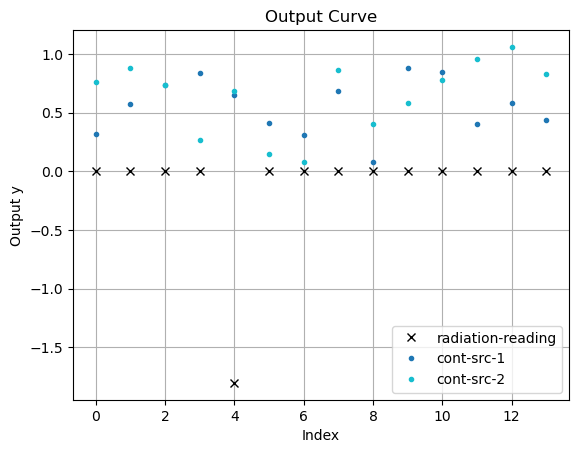

In [15]:
#Process data
%run data_handler.ipynb

In [16]:
X = inputs
y = outputs

In [17]:
%run ../common_functions.ipynb
# Initialize result collection
query_results = []

In [18]:
trainer = SurrogateTrainer(input_dim=X.shape[1])
trainer.fit(X, y)

influence = trainer.compute_input_influence(X, mode='global')
print("Feature influence:", influence)

Epoch 1/500, Loss: 1.024864
  model.0.weight: mean=-0.0343, std=0.4039
  model.0.bias: mean=-0.0319, std=0.3763
  model.2.weight: mean=-0.0003, std=0.0717
  model.2.bias: mean=-0.0066, std=0.0727
  model.4.weight: mean=0.0049, std=0.0687
  model.4.bias: mean=0.0466, std=nan
Epoch 50/500, Loss: 0.586616
  model.0.weight: mean=-0.0242, std=0.4210
  model.0.bias: mean=-0.0057, std=0.3794
  model.2.weight: mean=0.0025, std=0.0790
  model.2.bias: mean=0.0047, std=0.0790
  model.4.weight: mean=0.0098, std=0.0979
  model.4.bias: mean=-0.0015, std=nan
Epoch 100/500, Loss: 0.229617
  model.0.weight: mean=-0.0217, std=0.4479
  model.0.bias: mean=0.0205, std=0.3812
  model.2.weight: mean=0.0044, std=0.0935
  model.2.bias: mean=0.0137, std=0.0869
  model.4.weight: mean=0.0094, std=0.1377
  model.4.bias: mean=-0.0235, std=nan
Epoch 150/500, Loss: 0.123925
  model.0.weight: mean=-0.0262, std=0.4640
  model.0.bias: mean=0.0238, std=0.3757
  model.2.weight: mean=0.0053, std=0.1019
  model.2.bias: mean

/Users/ajay.amrite/Documents/AI Course/Anaconda Files/Module - 12/Black-Box functions/utils/SurrogateNN.py:60: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  print(f"  {name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")


In [ ]:
plt.bar(range(len(influence)), influence)
plt.xlabel("Feature Index")
plt.ylabel("Mean Gradient Magnitude")
plt.title("Feature Influence on Surrogate Predictions")
plt.show()